In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [13]:
df = pd.read_csv("/content/Weather_Data.csv")

df

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,W,41,S,SSW,...,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes,Yes
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,W,41,W,E,...,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes,Yes
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,W,41,ESE,ESE,...,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes,Yes
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,W,41,NNE,E,...,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes,Yes
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,W,41,NNE,W,...,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,6/21/2017,8.6,19.6,0.0,2.0,7.8,SSE,37,W,SSE,...,73,52,1025.9,1025.3,2,2,10.5,17.9,No,No
3267,6/22/2017,9.3,19.2,0.0,2.0,9.2,W,30,W,ESE,...,78,53,1028.5,1024.6,2,2,11.0,18.7,No,No
3268,6/23/2017,9.4,17.7,0.0,2.4,2.7,W,24,WNW,N,...,85,56,1020.8,1015.0,6,6,10.2,17.3,No,No
3269,6/24/2017,10.1,19.3,0.0,1.4,9.3,W,43,W,W,...,56,35,1017.3,1015.1,5,2,12.4,19.0,No,No


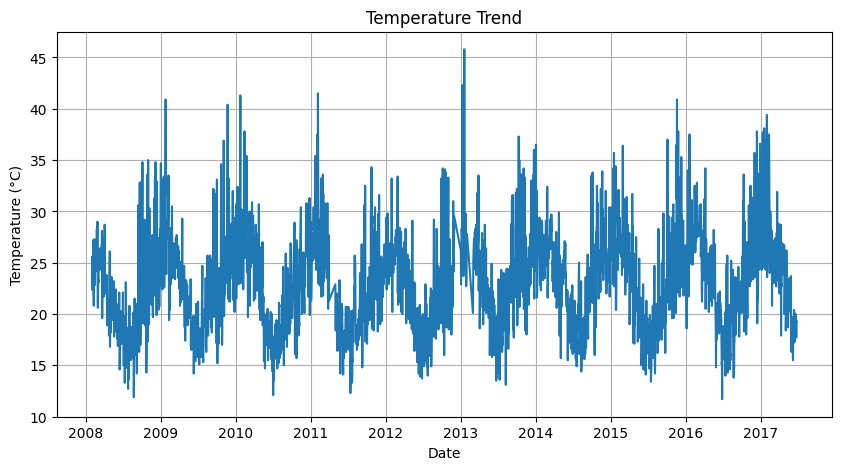

In [14]:
df = pd.read_csv("/content/Weather_Data.csv")

df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['MaxTemp'])
plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [15]:
df = pd.read_csv("/content/Weather_Data.csv")

df['Day'] = range(1, len(df)+1)

X = df[['Day']]
y = df['MaxTemp']

model = LinearRegression()
model.fit(X, y)

future_days = np.array([[len(df)+i] for i in range(1,31)])

future_days_df = pd.DataFrame(future_days, columns=['Day'])

predictions = model.predict(future_days_df)

print(predictions)

[23.90612236 23.90667282 23.90722329 23.90777375 23.90832421 23.90887468
 23.90942514 23.9099756  23.91052607 23.91107653 23.91162699 23.91217746
 23.91272792 23.91327839 23.91382885 23.91437931 23.91492978 23.91548024
 23.9160307  23.91658117 23.91713163 23.91768209 23.91823256 23.91878302
 23.91933348 23.91988395 23.92043441 23.92098487 23.92153534 23.9220858 ]


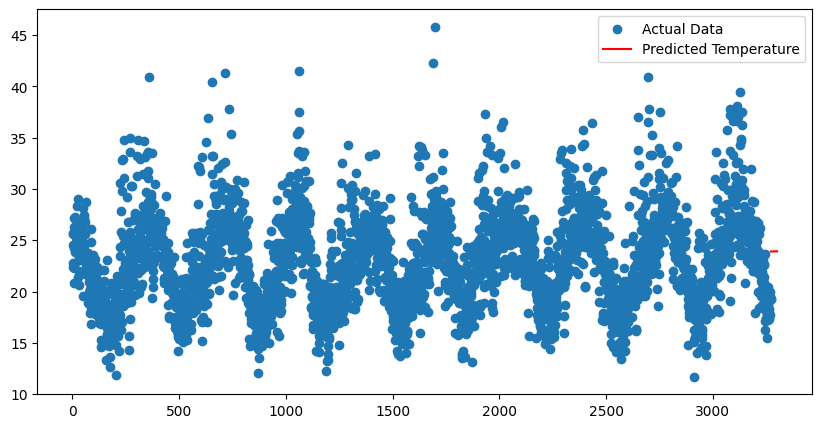

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    future_days,
    predictions,
    color='red',
    label='Predicted Temperature'
)

plt.legend()
plt.show()